# Φάση Δ: Advanced Technique

Εμείς επιλέξαμε το K-Means


# Εκκίνηση SparkSession & Φόρτωση Δεδομένων

In [59]:
from pyspark.sql import SparkSession

# 1. Εκκίνηση του SparkSession
spark = SparkSession.builder \
    .appName("KMeans_Feature_Exploration") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("SparkSession αρχικοποιήθηκε με επιτυχία.")

# 2. Φόρτωση των DataFrames
df_silver = spark.read.parquet("../data/train_silver.parquet")
train_gold = spark.read.parquet("../data/train_gold.parquet")

print(f"Δεδομένα φορτώθηκαν. Gold Layer σχήμα: {train_gold.schema}")

SparkSession αρχικοποιήθηκε με επιτυχία.
Δεδομένα φορτώθηκαν. Gold Layer σχήμα: StructType([StructField('features', VectorUDT(), True), StructField('stroke', LongType(), True)])


26/06/09 15:16:50 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


# Εμφάνιση χαρακτηριστικών του Gold Layer

In [60]:
import pyspark.sql.functions as F
from pyspark.ml.functions import vector_to_array
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

# 1. Βρούμε τις κατηγορικές στήλες (_index) και εξάγουμε τα labels από τα Metadata
cat_cols = [field.name for field in df_silver.schema.fields if field.name.endswith("_index")]
human_categorical_names = []

for col in cat_cols:
    metadata = df_silver.schema[col].metadata
    # Αν υπάρχουν metadata από τον StringIndexer, παίρνουμε τα vals
    if "ml_attr" in metadata and "vals" in metadata["ml_attr"]:
        distinct_vals = metadata["ml_attr"]["vals"]
    else:
        # Fallback native ανάγνωση αν λείπουν τα metadata
        original_col_name = col.replace("_index", "")
        distinct_vals = [str(row[0]) for row in df_silver.select(original_col_name).distinct().sort(col).collect()]
    
    # Το OneHotEncoder (dropLast=True) αφαιρεί πάντα την τελευταία τιμή
    kept_vals = distinct_vals[:-1]
    original_col_name = col.replace("_index", "")
    for val in kept_vals:
        human_categorical_names.append(f"{original_col_name}_{val}")

# 2. Βρούμε τις αριθμητικές στήλες με τη σωστή σειρά
spark_numeric_types = (IntegerType, DoubleType, FloatType, LongType)
all_numeric_cols = [field.name for field in df_silver.schema.fields if isinstance(field.dataType, spark_numeric_types)]
numeric_cols = [c for c in all_numeric_cols if c != "stroke" and not c.endswith("_index")]

# 3. Ενώνουμε τις λίστες με την ακριβή σειρά που μπήκαν στον VectorAssembler (Categorical Vector + Numeric)
feature_names = human_categorical_names + numeric_cols
print(f"Συνολικά βρέθηκαν {len(feature_names)} διαστάσεις στο feature vector.")

# 4. Μετατροπή του Vector σε Array στο train_gold
df_look = train_gold.withColumn("features_array", vector_to_array("features"))

# 5. Χτίζουμε δυναμικά το select expresssion για ΟΛΕΣ τις στήλες
select_exprs = [F.col("stroke")]
for i, name in enumerate(feature_names):
    select_exprs.append(F.col("features_array")[i].alias(name))

# 6. Προβολή των 5 πρώτων γραμμών με όλα τα χαρακτηριστικά επεξηγημένα
df_look.select(select_exprs).show(5, truncate=False)

Συνολικά βρέθηκαν 21 διαστάσεις στο feature vector.
+------+-----------------+-----------------+------------+------------------+---------------+-----------------+-----------------------+------------------+------------------+----------------------+--------------------+--------------------+---------------------------+----------------------+------------------------------+---------------------+------------------+------------+-------------+------------------+-----------------+
|stroke|gender_Female    |gender_Male      |gender_Other|ever_married_Yes  |ever_married_No|work_type_Private|work_type_Self-employed|work_type_children|work_type_Govt_job|work_type_Never_worked|Residence_type_Urban|Residence_type_Rural|smoking_status_never smoked|smoking_status_Unknown|smoking_status_formerly smoked|smoking_status_smokes|age               |hypertension|heart_disease|avg_glucose_level |bmi              |
+------+-----------------+-----------------+------------+------------------+---------------+------

# Εφαρμογή βαρών στο gold για Feature Engineering

In [61]:
from pyspark.ml.linalg import Vectors, VectorUDT
import numpy as np

# 1. Δημιουργούμε έναν πίνακα με βάρη (αρχικά όλα 1.0) ίσο με το μέγεθος των features
num_features = len(feature_names)
weights_array = np.ones(num_features)

# --- ΕΔΩ ΟΡΙΖΕΙΣ ΤΑ ΒΑΡΗ ΣΟΥ ---
# Παράδειγμα: Αν θες να σβήσεις τις θέσεις 2 και 3, ή να δώσεις βάρος 2.5 στην ηλικία:
# weights_array[2] = 0.0 
# weights_array[3] = 0.0
# weights_array[feature_names.index("age")] = 2.5
# ------------------------------

print(f"Πίνακας βαρών: {weights_array}")

# 2. UDF για element-wise πολλαπλασιασμό του vector με τα βάρη
apply_weights_udf = F.udf(lambda vec: Vectors.dense(vec.toArray() * weights_array), VectorUDT())

# 3. Δημιουργία του modified_gold στην μνήμη χωρίς να αλλάξουμε το αρχικό αρχείο
modified_gold = train_gold.withColumn("features", apply_weights_udf("features"))

print("Το modified_gold δημιουργήθηκε και είναι έτοιμο για εκπαίδευση.")

Πίνακας βαρών: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Το modified_gold δημιουργήθηκε και είναι έτοιμο για εκπαίδευση.


# Elbow Method & Silhouette Score πάνω στο modified_gold

Μας βοηθάει να επιλέξουμε το σωστό k για το k-Means

Έναρξη αξιολόγησης του modified_gold...
Εκπαίδευση μοντέλου για K = 2...


 -> K = 2: WSSSE = 139595.55 | Silhouette Score = 0.4433
Εκπαίδευση μοντέλου για K = 3...


 -> K = 3: WSSSE = 136323.58 | Silhouette Score = 0.1774
Εκπαίδευση μοντέλου για K = 4...


 -> K = 4: WSSSE = 117132.24 | Silhouette Score = 0.2284
Εκπαίδευση μοντέλου για K = 5...


 -> K = 5: WSSSE = 107692.13 | Silhouette Score = 0.2606
Εκπαίδευση μοντέλου για K = 6...


 -> K = 6: WSSSE = 99573.13 | Silhouette Score = 0.2863
Εκπαίδευση μοντέλου για K = 7...


 -> K = 7: WSSSE = 95087.57 | Silhouette Score = 0.2806
Εκπαίδευση μοντέλου για K = 8...


 -> K = 8: WSSSE = 90680.53 | Silhouette Score = 0.2813


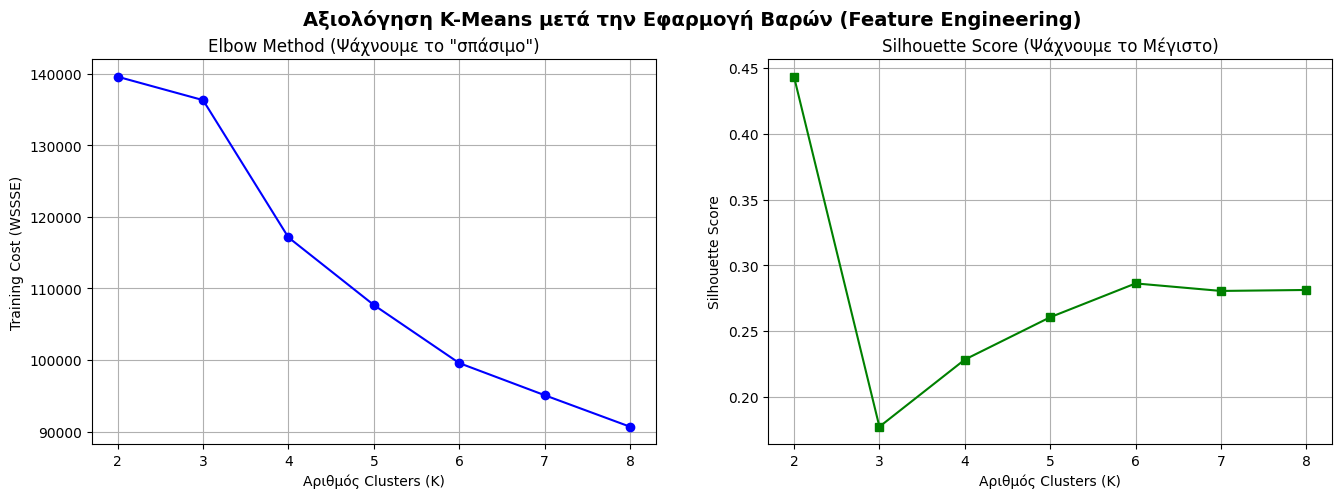

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("Έναρξη αξιολόγησης του modified_gold...")

# 1. Αρχικοποίηση λιστών για την αποθήκευση των μετρικών
costs = []
silhouette_scores = []
k_range = range(2, 9)  # Δοκιμάζουμε Κ από 2 έως 8 όπως στην αρχική μελέτη

# 2. Ορισμός του Evaluator για το Silhouette Score
evaluator = ClusteringEvaluator(
    predictionCol="cluster", 
    featuresCol="features", 
    metricName="silhouette"
)

# 3. Εκτέλεση του Loop για κάθε K
for k_val in k_range:
    print(f"Εκπαίδευση μοντέλου για K = {k_val}...")
    
    # Ορισμός και εκπαίδευση του KMeans με σταθερό seed για αναπαραγωγιμότητα
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k_val, seed=42)
    model = km.fit(modified_gold)
    
    # α) Υπολογισμός Training Cost (WSSSE) για την Elbow Method
    cost = model.summary.trainingCost
    costs.append(cost)
    
    # β) Παραγωγή προβλέψεων και υπολογισμός Silhouette Score
    predictions = model.transform(modified_gold)
    score = evaluator.evaluate(predictions)
    silhouette_scores.append(score)
    
    print(f" -> K = {k_val}: WSSSE = {cost:.2f} | Silhouette Score = {score:.4f}")

# 4. Σχεδίαση Γραφημάτων (Δίπλα-Δίπλα για εύκολη σύγκριση)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Γράφημα 1: Elbow Method
ax1.plot(list(k_range), costs, marker='o', linestyle='-', color='b')
ax1.set_xlabel('Αριθμός Clusters (K)')
ax1.set_ylabel('Training Cost (WSSSE)')
ax1.set_title('Elbow Method (Ψάχνουμε το "σπάσιμο")')
ax1.grid(True)

# Γράφημα 2: Silhouette Score
ax2.plot(list(k_range), silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_xlabel('Αριθμός Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (Ψάχνουμε το Μέγιστο)')
ax2.grid(True)

plt.suptitle('Αξιολόγηση K-Means μετά την Εφαρμογή Βαρών (Feature Engineering)', fontsize=14, fontweight='bold')
plt.show()

# Ορθή Εφαρμογή PCA σε Train και Test Sets


In [63]:
from pyspark.ml.feature import PCA
import pyspark.sql.functions as F

print("Έναρξη διαδικασίας μείωσης διαστασιμότητας με PCA (k=2)...")

# 1. Φόρτωση και του test_gold (αν δεν είναι ήδη φορτωμένο)
test_gold = spark.read.parquet("../data/test_gold.parquet")

# 2. Ορισμός του PCA μοντέλου
# Επιλέγουμε k=2 κυρίως συστατώσες για να μπορούμε να κάνουμε 2D οπτικοποίηση
pca = PCA(k=2, inputCol="features", outputCol="pca_features")

# 3. ΕΚΠΑΙΔΕΥΣΗ (Fit) ΜΟΝΟ ΣΤΟ TRAIN GOLD
# Υπολογισμός των ιδιοδιανυσμάτων αποκλειστικά από τα δεδομένα εκπαίδευσης
pca_model = pca.fit(train_gold)

# 4. ΜΕΤΑΣΧΗΜΑΤΙΣΜΟΣ (Transform) ΚΑΙ ΣΤΑ ΔΥΟ DATASETS
# Εφαρμόζουμε την ίδια ακριβώς προβολή και στα δύο σύνολα
train_pca = pca_model.transform(train_gold)
test_pca = pca_model.transform(test_gold)

# 5. Επιβεβαίωση αποτελεσμάτων και εμφάνιση δείγματος
print("\n=== TRAIN DATASET ΜΕ PCA FEATURES ===")
train_pca.select("stroke", "features", "pca_features").show(3, truncate=True)

print("=== TEST DATASET ΜΕ PCA FEATURES ===")
test_pca.select("stroke", "features", "pca_features").show(3, truncate=True)

# Επεξήγηση της διακύμανσης (Explained Variance)
explained_variance = pca_model.explainedVariance
print(f"\nΠοσοστό πληροφορίας που διατηρήθηκε:")
print(f" -> PC1: {explained_variance[0]*100:.2f}%")
print(f" -> PC2: {explained_variance[1]*100:.2f}%")
print(f" -> Συνολική πληροφορία (PC1 + PC2): {sum(explained_variance)*100:.2f}%")

Έναρξη διαδικασίας μείωσης διαστασιμότητας με PCA (k=2)...

=== TRAIN DATASET ΜΕ PCA FEATURES ===
+------+--------------------+--------------------+
|stroke|            features|        pca_features|
+------+--------------------+--------------------+
|     1|(21,[1,3,6,11,15,...|[3.77838097358701...|
|     1|(21,[0,3,5,11,13,...|[3.24350473472570...|
|     1|(21,[1,3,5,11,12,...|[4.50903673772673...|
+------+--------------------+--------------------+
only showing top 3 rows
=== TEST DATASET ΜΕ PCA FEATURES ===
+------+--------------------+--------------------+
|stroke|            features|        pca_features|
+------+--------------------+--------------------+
|     0|(21,[0,4,7,11,13,...|[-2.7579359847908...|
|     0|(21,[0,4,7,11,13,...|[-2.5739401657464...|
|     0|(21,[0,4,7,10,13,...|[-2.5704807508333...|
+------+--------------------+--------------------+
only showing top 3 rows

Ποσοστό πληροφορίας που διατηρήθηκε:
 -> PC1: 18.22%
 -> PC2: 11.72%
 -> Συνολική πληροφορία (PC1 + PC

Εκπαίδευση K-Means (K=2) πάνω στα PCA χαρακτηριστικά...


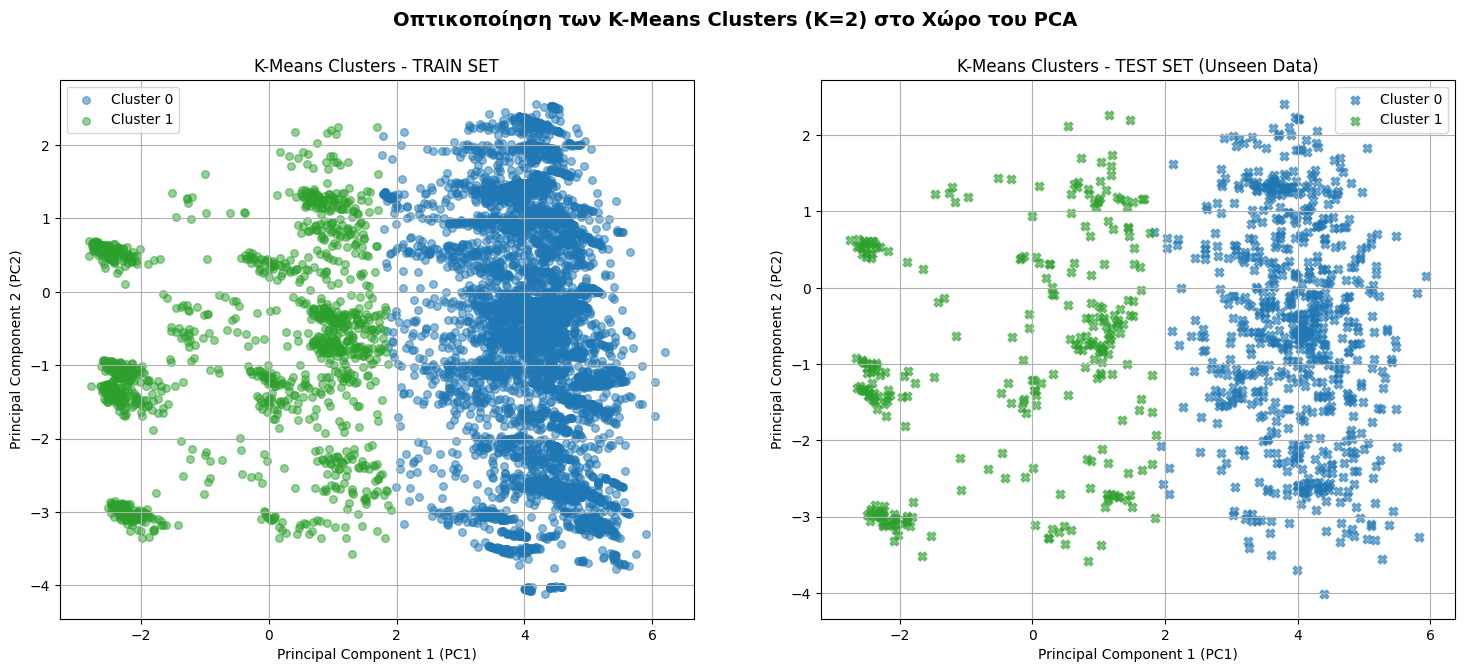

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.clustering import KMeans

print("Εκπαίδευση K-Means (K=2) πάνω στα PCA χαρακτηριστικά...")

# 1. Ορισμός και εκπαίδευση του μοντέλου KMeans στα PCA χαρακτηριστικά του Train set
kmeans_pca = KMeans(featuresCol="pca_features", predictionCol="cluster", k=2, seed=42)
model_pca = kmeans_pca.fit(train_pca)

# 2. Παραγωγή προβλέψεων (Cluster Assignments) για Train και Test
train_preds = model_pca.transform(train_pca)
test_preds = model_pca.transform(test_pca)

# 3. Μετατροπή σε Pandas ΜΟΝΟ για τη σχεδίαση των γραφημάτων
plot_train_df = train_preds.select("pca_features", "cluster").toPandas()
plot_test_df = test_preds.select("pca_features", "cluster").toPandas()

# Συνάρτηση για την εξαγωγή των PC1 και PC2 από το Vector σε ξεχωριστές στήλες Pandas
def extract_pcs(df):
    df['PC1'] = df['pca_features'].apply(lambda vec: float(vec[0]))
    df['PC2'] = df['pca_features'].apply(lambda vec: float(vec[1]))
    return df

plot_train_df = extract_pcs(plot_train_df)
plot_test_df = extract_pcs(plot_test_df)

# 4. Δημιουργία των Γραφημάτων (Δίπλα-Δίπλα)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
colors = {0: '#1f77b4', 1: '#2ca02c'}  # Μπλε για το Cluster 0, Πράσινο για το Cluster 1

# Γράφημα Α: Train Set Clusters
for cluster_id in sorted(plot_train_df['cluster'].unique()):
    cluster_data = plot_train_df[plot_train_df['cluster'] == cluster_id]
    ax1.scatter(
        cluster_data['PC1'], cluster_data['PC2'],
        color=colors[cluster_id], alpha=0.5, s=30,
        label=f'Cluster {cluster_id}'
    )
ax1.set_xlabel('Principal Component 1 (PC1)')
ax1.set_ylabel('Principal Component 2 (PC2)')
ax1.set_title('K-Means Clusters - TRAIN SET')
ax1.legend()
ax1.grid(True)

# Γράφημα Β: Test Set Clusters (Γενίκευση Μοντέλου)
for cluster_id in sorted(plot_test_df['cluster'].unique()):
    cluster_data = plot_test_df[plot_test_df['cluster'] == cluster_id]
    ax2.scatter(
        cluster_data['PC1'], cluster_data['PC2'],
        color=colors[cluster_id], alpha=0.6, s=40, marker='X',
        label=f'Cluster {cluster_id}'
    )
ax2.set_xlabel('Principal Component 1 (PC1)')
ax2.set_ylabel('Principal Component 2 (PC2)')
ax2.set_title('K-Means Clusters - TEST SET (Unseen Data)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Οπτικοποίηση των K-Means Clusters (K=2) στο Χώρο του PCA', fontsize=14, fontweight='bold')
plt.show()

# Εκπαίδευση στο Train και Πρόβλεψη στο Test Dataset

In [72]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("Έναρξη εκπαίδευσης του K-Means (K=2) στο Training Dataset...")

# 1. Ορισμός του μοντέλου K-Means με βάση τις παραμέτρους της ομάδας σας
# Χρησιμοποιούμε k=2 και το συγκεκριμένο seed για σταθερά αποτελέσματα
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=2, seed=22390225)

# 2. ΕΚΠΑΙΔΕΥΣΗ (Fit) αποκλειστικά στο Training Dataset
kmeans_model = kmeans.fit(train_gold)
print("Η εκπαίδευση του μοντέλου ολοκληρώθηκε.")

# 3. ΕΦΑΡΜΟΓΗ (Transform) στο Test Dataset για την παραγωγή προβλέψεων
test_preds = kmeans_model.transform(test_gold)
print("Οι προβλέψεις στο Test Dataset δημιουργήθηκαν.")

# 4. ΑΞΙΟΛΟΓΗΣΗ: Υπολογισμός του Silhouette Score στο Test Dataset
evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="features", metricName="silhouette")
test_silhouette = evaluator.evaluate(test_preds)

print("\n=================== ΑΠΟΤΕΛΕΣΜΑΤΑ TEST SET ===================")
print(f"Silhouette Score στα άγνωστα δεδομένα (Test Set): {test_silhouette:.4f}")

# 5. Εμφάνιση δείγματος των αποτελεσμάτων (Cluster Assignments) μαζί με το πραγματικό stroke
print("\nΔείγμα προβλέψεων από το Test Set:")
test_preds.select("stroke", "cluster").show(10, truncate=False)

Έναρξη εκπαίδευσης του K-Means (K=2) στο Training Dataset...
Η εκπαίδευση του μοντέλου ολοκληρώθηκε.
Οι προβλέψεις στο Test Dataset δημιουργήθηκαν.

=================== ΑΠΟΤΕΛΕΣΜΑΤΑ TEST SET ===================
Silhouette Score στα άγνωστα δεδομένα (Test Set): 0.1333

Δείγμα προβλέψεων από το Test Set:
+------+-------+
|stroke|cluster|
+------+-------+
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
+------+-------+
only showing top 10 rows


In [65]:
# Φάση Δ: Advanced Technique 
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.fpm import FPGrowth
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import PCA

spark = SparkSession.builder \
    .appName("Advanced_Techniques") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# --- 1. ASSOCIATION RULES ---
print("Εξαγωγή Κανόνων Συσχέτισης...")
df_silver = spark.read.parquet("../data/train_silver.parquet")

transactions_df = df_silver.withColumn(
    "items",
    F.array_remove(F.array(
        F.when(F.col("stroke") == 1, "Stroke").otherwise(""),
        F.when(F.col("hypertension") == 1, "Hypertension").otherwise(""),
        F.when(F.col("heart_disease") == 1, "Heart_Disease").otherwise(""),
        F.when(F.col("age") > 65, "Age_>_65").otherwise("")
    ), "")
).filter(F.size("items") > 0).select("items")

fpGrowth = FPGrowth(itemsCol="items", minSupport=0.01, minConfidence=0.1) 
rules = fpGrowth.fit(transactions_df).associationRules

print("Κανόνες Κινδύνου για Εγκεφαλικό:")
rules.filter(F.array_contains(F.col("consequent"), "Stroke")).sort(F.col("lift").desc()).show(truncate=False)

# --- 2. CLUSTERING (K-MEANS) ---
print("Εκτέλεση K-Means...")
train_gold = spark.read.parquet("../data/train_gold.parquet")
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=2, seed=22390225)
#kmeans = KMeans(featuresCol="features", predictionCol="cluster", seed=22390225)

kmeans_algo = kmeans.fit(train_gold)

kmeans_preds = kmeans_algo.transform(train_gold)
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
kmeans_pca = pca.fit(kmeans_preds).transform(kmeans_preds)

kmeans_pca.select("stroke", "cluster", "pca_features").write.mode("overwrite").parquet("../data/preds_kmeans.parquet")
#spark.stop()

26/06/09 15:17:10 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Εξαγωγή Κανόνων Συσχέτισης...
Κανόνες Κινδύνου για Εγκεφαλικό:
+-------------------------+----------+-------------------+------------------+--------------------+
|antecedent               |consequent|confidence         |lift              |support             |
+-------------------------+----------+-------------------+------------------+--------------------+
|[Hypertension, Age_>_65] |[Stroke]  |0.23076923076923078|1.2396878483835005|0.03776978417266187 |
|[Heart_Disease, Age_>_65]|[Stroke]  |0.21014492753623187|1.128894489953091 |0.026079136690647483|
|[Heart_Disease]          |[Stroke]  |0.18018018018018017|0.9679244461853157|0.03597122302158273 |
|[Age_>_65]               |[Stroke]  |0.1671018276762402 |0.8976677892559377|0.11510791366906475 |
|[Hypertension]           |[Stroke]  |0.14039408866995073|0.7541943314057257|0.051258992805755396|
+-------------------------+----------+-------------------+------------------+--------------------+

Εκτέλεση K-Means...


Εύρεση βέλτιστου K με την Elbow Method...
Για K = 2, το Training Cost (WSSSE) είναι: 139595.55
Για K = 3, το Training Cost (WSSSE) είναι: 136323.58
Για K = 4, το Training Cost (WSSSE) είναι: 117132.24
Για K = 5, το Training Cost (WSSSE) είναι: 107692.13
Για K = 6, το Training Cost (WSSSE) είναι: 99573.13
Για K = 7, το Training Cost (WSSSE) είναι: 95087.57
Για K = 8, το Training Cost (WSSSE) είναι: 90680.53


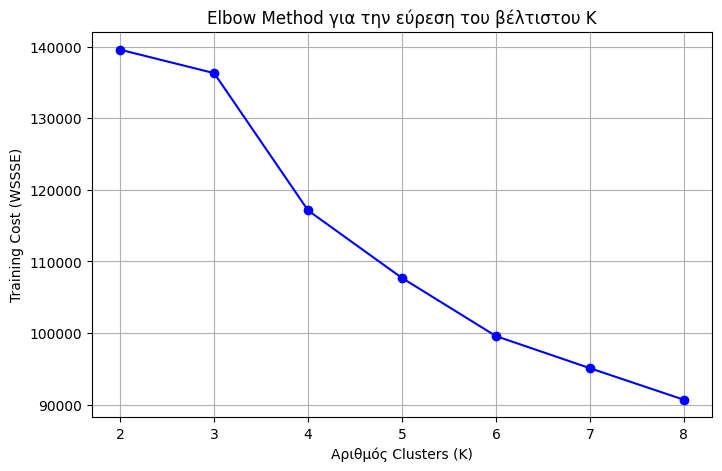

In [66]:
# K Means μέσω Elbow Method
# Kmeans μέσω elbow method
import matplotlib.pyplot as plt
import pandas as pd

print("Εύρεση βέλτιστου K με την Elbow Method...")

# Διαβάζουμε τα χρυσά δεδομένα (αν δεν είναι ήδη φορτωμένα)
train_gold = spark.read.parquet("../data/train_gold.parquet")

# Λίστα για την αποθήκευση του κόστους (Within Set Sum of Squared Errors)
costs = []
k_range = range(2, 9)  # Δοκιμάζουμε k από 2 έως 8

for k_val in k_range:
    # Εκπαίδευση του μοντέλου για το τρέχον k
    km = KMeans(featuresCol="features", k=k_val, seed=42)
    model = km.fit(train_gold)
    
    # Στο PySpark, το trainingCost μας δίνει το WSSSE
    cost = model.summary.trainingCost
    costs.append(cost)
    print(f"Για K = {k_val}, το Training Cost (WSSSE) είναι: {cost:.2f}")

# Δημιουργία γραφήματος για την οπτικοποίηση του "αγκώνα"
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), costs, marker='o', linestyle='-', color='b')
plt.xlabel('Αριθμός Clusters (K)')
plt.ylabel('Training Cost (WSSSE)')
plt.title('Elbow Method για την εύρεση του βέλτιστου K')
plt.grid(True)
plt.show()

# --- Σημείωση: Αφού δεις το γράφημα, επιλέγεις το K εκεί που "σπάει" η καμπύλη ---

Εύρεση βέλτιστου K με το Silhouette Score...
Για K = 2, το Silhouette Score είναι: 0.4433
Για K = 3, το Silhouette Score είναι: 0.1774
Για K = 4, το Silhouette Score είναι: 0.2284
Για K = 5, το Silhouette Score είναι: 0.2606
Για K = 6, το Silhouette Score είναι: 0.2863
Για K = 7, το Silhouette Score είναι: 0.2806
Για K = 8, το Silhouette Score είναι: 0.2813


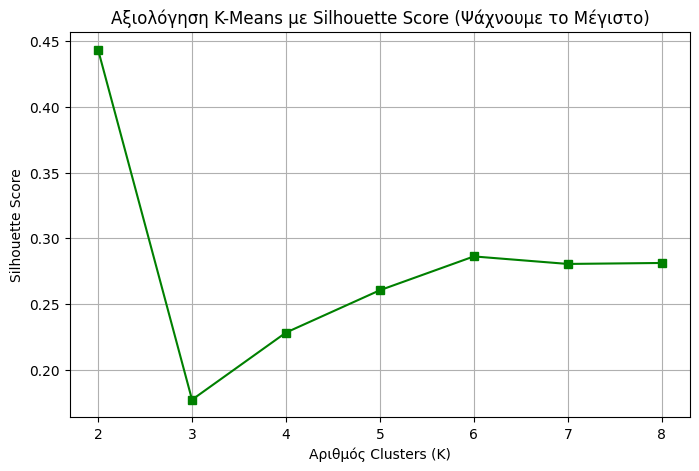

In [67]:
# K Means μέσω Silhouette Score
# K Means μέσω Silhouette Score
import matplotlib.pyplot as plt
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("Εύρεση βέλτιστου K με το Silhouette Score...")

# Υποθέτουμε ότι το train_gold υπάρχει ήδη (π.χ. train_gold = spark.read.parquet("../data/train_gold.parquet"))

silhouette_scores = []
k_range = range(2, 9)  # Δοκιμάζουμε K από 2 έως 8

# Ορίζουμε τον Αξιολογητή (Evaluator)
# Σημείωση: Χρησιμοποιούμε predictionCol="cluster" όπως το είχες ορίσει αρχικά
evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="features", metricName="silhouette")

for k_val in k_range:
    # 1. Ορισμός και εκπαίδευση του μοντέλου
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k_val, seed=42)
    model = km.fit(train_gold)
    
    # 2. Παραγωγή προβλέψεων (τα assignments στα clusters)
    predictions = model.transform(train_gold)
    
    # 3. Υπολογισμός του Silhouette Score
    score = evaluator.evaluate(predictions)
    silhouette_scores.append(score)
    print(f"Για K = {k_val}, το Silhouette Score είναι: {score:.4f}")

# Δημιουργία γραφήματος για την οπτικοποίηση των σκορ
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='s', linestyle='-', color='g')
plt.xlabel('Αριθμός Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Αξιολόγηση K-Means με Silhouette Score (Ψάχνουμε το Μέγιστο)')
plt.grid(True)
plt.show()

# --- Σημείωση: Επίλεξε το K που αντιστοιχεί στο υψηλότερο σημείο του γραφήματος ---

Προετοιμασία δεδομένων για το Plot των K-Means Clusters...


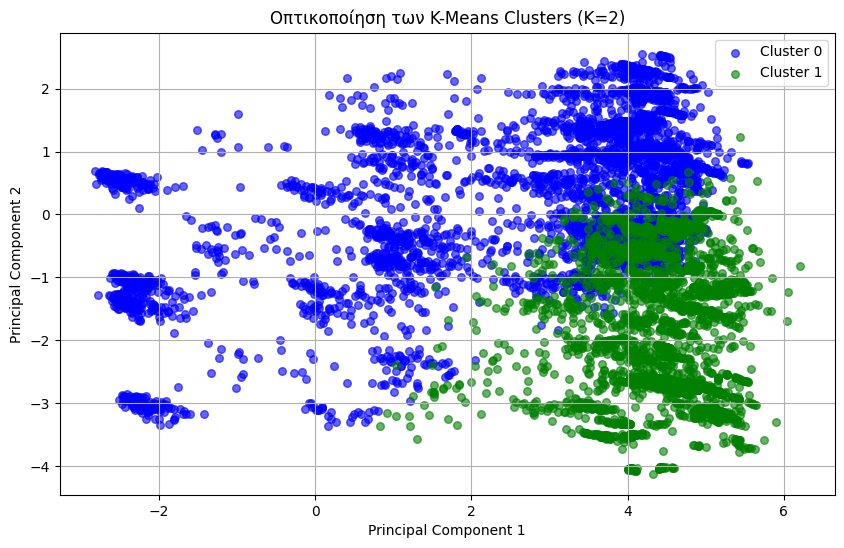

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

print("Προετοιμασία δεδομένων για το Plot των K-Means Clusters...")
# Προσοχή: Εδώ επιλέγουμε τη στήλη 'cluster', ΟΧΙ το 'stroke'
plot_df = kmeans_pca.select("pca_features", "cluster").toPandas()

# Εξαγωγή των PC1 και PC2
plot_df['PC1'] = plot_df['pca_features'].apply(lambda vec: float(vec[0]))
plot_df['PC2'] = plot_df['pca_features'].apply(lambda vec: float(vec[1]))

plt.figure(figsize=(10, 6))

# Ορίζουμε 3 χρώματα για τα 3 clusters (0, 1, 2)
colors = {0: 'blue', 1: 'green', 2: 'red'}

# Φτιάχνουμε τα σημεία για κάθε cluster
for cluster_id in sorted(plot_df['cluster'].unique()):
    cluster_data = plot_df[plot_df['cluster'] == cluster_id]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], 
                alpha=0.6, label=f'Cluster {cluster_id}', 
                color=colors.get(cluster_id, 'black'), s=30)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Οπτικοποίηση των K-Means Clusters (K={kmeans.getK()})')
plt.legend()
plt.grid(True)
plt.show()

In [69]:

test_gold = spark.read.parquet("../data/test_gold.parquet")
# 3. Παραγωγή προβλέψεων στο ΠΡΑΓΜΑΤΙΚΟ test set χρησιμοποιώντας το ΜΟΝΤΕΛΟ
test_preds = kmeans_algo.transform(test_gold)

# 4. Μετατροπή σε Pandas και υπολογισμός
import pandas as pd
pdf_true_test = test_preds.select("cluster", "stroke").toPandas()

print("==================================================")
print("ΠΡΑΓΜΑΤΙΚΟ TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER")
print("==================================================")
stroke_profile_test = pdf_true_test.groupby("cluster").mean() * 100
print(stroke_profile_test.round(1).to_string())

ΠΡΑΓΜΑΤΙΚΟ TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER
         stroke
cluster        
0           3.5
1           5.8


In [70]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F

# 1. Φόρτωση των DataFrames
df_silver = spark.read.parquet("../data/train_silver.parquet")
train_gold = spark.read.parquet("../data/train_gold.parquet")

# 2. Native PySpark Extraction των Categorical Labels από τα Metadata
human_categorical_names = []
cat_cols = [field.name for field in df_silver.schema.fields if field.name.endswith("_index")]

for col in cat_cols:
    # Παίρνουμε τα metadata της στήλης
    metadata = df_silver.schema[col].metadata
    
    # Αν η στήλη έχει περάσει από StringIndexer, τα labels υπάρχουν έτοιμα εδώ:
    if "ml_attr" in metadata and "vals" in metadata["ml_attr"]:
        distinct_vals = metadata["ml_attr"]["vals"]
    else:
        # Fallback αν δεν υπάρχουν metadata (διαβάζουμε τις τιμές native)
        original_col_name = col.replace("_index", "")
        distinct_vals = [str(row[0]) for row in df_silver.select(original_col_name).distinct().sort(col).collect()]
    
    # Το OneHotEncoder (dropLast=True) πετάει πάντα την τελευταία τιμή
    kept_vals = distinct_vals[:-1]
    
    # Φτιάχνουμε τα τελικά ονόματα
    original_col_name = col.replace("_index", "")
    for val in kept_vals:
        human_categorical_names.append(f"{original_col_name}_{val}")

num_cat_features = len(human_categorical_names)

# 3. Μετατροπή των predictions σε Pandas (Μόνο για το τελικό group/report)
pdf_gold = test_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# 4. Απομόνωση του categorical κομματιού και δημιουργία του DataFrame
cat_features_matrix = features_matrix[:, 0:num_cat_features]
cat_features_binary = (cat_features_matrix > 0.001).astype(int)

pdf_cat_human = pd.DataFrame(cat_features_binary, columns=human_categorical_names)
pdf_cat_human['cluster'] = pdf_gold['cluster']

# 5. Τελικό Report Ποσοστών
print("\n" + "="*80)
print("=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*80)
cat_profile_human = pdf_cat_human.groupby('cluster').mean() * 100
print(cat_profile_human.round(1).T.to_string())


=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===
cluster                            0     1
gender_Female                   78.8   8.3
gender_Male                     21.2  91.7
gender_Other                     0.0   0.0
ever_married_Yes                54.8  95.4
ever_married_No                 45.2   4.6
work_type_Private               52.9  64.2
work_type_Self-employed         15.0  20.8
work_type_children              18.3   0.0
work_type_Govt_job              13.2  15.0
work_type_Never_worked           0.6   0.0
Residence_type_Urban            51.1  55.4
Residence_type_Rural            48.9  44.6
smoking_status_never smoked     38.6  32.7
smoking_status_Unknown          37.6  19.9
smoking_status_formerly smoked  12.0  28.1
smoking_status_smokes           11.8  19.3


In [71]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

# 1. Φόρτωση του Silver DataFrame (για τον υπολογισμό των STDs)
df_silver = spark.read.parquet("../data/train_silver.parquet")

# ==========================================
# ΑΥΤΟΜΑΤΟΣ ΔΙΑΧΩΡΙΣΜΟΣ ΜΕ NATIVE PYSPARK (FIXED)
# ==========================================
spark_numeric_types = (IntegerType, DoubleType, FloatType, LongType)
all_numeric_cols = [field.name for field in df_silver.schema.fields if isinstance(field.dataType, spark_numeric_types)]

numeric_cols = [c for c in all_numeric_cols if c != "stroke" and not c.endswith("_index")]
cat_cols = [c for c in all_numeric_cols if c.endswith("_index")]

# 2. Native PySpark Υπολογισμός των STDs (απαραίτητο για το ξε-κανονικοποίηση)
std_exprs = [F.stddev_samp(F.col(c)).alias(c) for c in numeric_cols]
stds_dict = df_silver.select(*std_exprs).first().asDict()

# 3. Εξαγωγή των scaled αριθμητικών χαρακτηριστικών από το Test Προβλέψεων
pdf_gold = test_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# Βρίσκουμε δυναμικά πού ξεκινούν οι αριθμητικές στήλες στο vector
num_cat_features = features_matrix.shape[1] - len(numeric_cols)
numeric_features_scaled = features_matrix[:, num_cat_features:]

# 4. Δημιουργία DataFrame με τις ΠΡΑΓΜΑΤΙΚΕΣ (Unscaled) τιμές
pdf_numeric_unscaled = pd.DataFrame(columns=numeric_cols)
for i, col in enumerate(numeric_cols):
    pdf_numeric_unscaled[col] = numeric_features_scaled[:, i] * stds_dict[col]

# Προσθήκη της στήλης του cluster
pdf_numeric_unscaled['cluster'] = pdf_gold['cluster']

# 5. Τελικό Report ανά Cluster
print("\n" + "="*90)
print("=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*90)

cluster_profiles = pdf_numeric_unscaled.groupby('cluster')[numeric_cols].agg(['mean', 'min', 'max', 'std'])

for cluster_id in sorted(pdf_numeric_unscaled['cluster'].unique()):
    print(f"\n--- CLUSTER {cluster_id} ---")
    print(cluster_profiles.loc[cluster_id].unstack(level=1).round(2).to_string())


=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===

--- CLUSTER 0 ---
                    mean    min     max    std
age                38.84   0.08   83.12  23.36
hypertension        0.05   0.00    1.01   0.22
heart_disease       0.02   0.00    1.05   0.15
avg_glucose_level  82.51  45.02  216.87  31.91
bmi                32.84  13.31   72.54   9.09

--- CLUSTER 1 ---
                     mean    min     max    std
age                 58.04  21.29   83.12  15.12
hypertension         0.18   0.00    1.01   0.39
heart_disease        0.13   0.00    1.05   0.35
avg_glucose_level  102.15  45.65  221.06  48.92
bmi                 37.46  24.02   76.31   8.07
